# Instructions
Before you start this lesson please click the "Run all" button at the top of the page:

![Screenshot showing run all button](https://github.com/catvec/putney-mit-technology-camp/blob/main/assets/what-is-ai/run-all-button.png?raw=true)

This might take about a minute or more.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
import IPython.display as display
import skimage
import torch

# What is AI?
- Artificial intelligence as we speak about it today is more accurately called "Machine learning"
- A machine learning **model** is a program that when given an input tries to predict an output
- They learn patterns from the past and try to predict the future

# Patterns
Humans are pretty good at learning patterns. Let's give it a shot:

## Plant Growing
Let's look how plants grow in the sun. Specifically how tall they get when we water them:

![Photo of a plant growing](https://github.com/catvec/putney-mit-technology-camp/blob/main/assets/what-is-ai/plant-growing.jpg?raw=true)

Each day the plan grows by a certain number of centimeters. Here is a graph of their day to day growth:

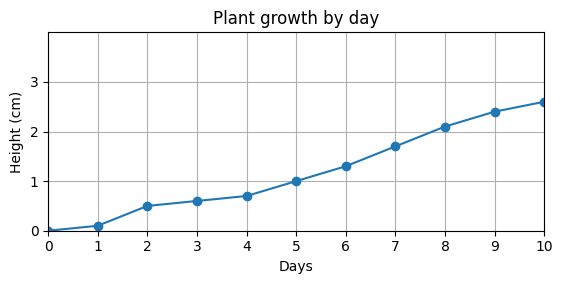

In [ ]:
# @title
# Graph of plant growth
plt.plot(
    np.arange(0, 11, 1),
    [0, 0.1, 0.5, 0.6, 0.7, 1, 1.3, 1.7, 2.1, 2.4, 2.6],
    marker='o',
)
plt.gca().set_xlabel("Days")
plt.gca().set_ylabel("Height (cm)")
plt.gca().set_xlim([0, 10])
plt.gca().set_ylim([0, 4])
plt.gca().set_xticks(np.arange(0, 11, 1))
plt.gca().set_yticks(np.arange(0, 4, 1))
plt.gca().set_aspect(1)
plt.grid()
plt.title("Plant growth by day")

plt.show()

The plant starts off pretty slow, but then by day 5 it's growing 1cm every few days.

How can we predict the plants height in the future?

Let's take a quick diversion and learn about the:

# Slope Intercept Equation (aka $y = m \cdot x + b$)
In math class you've probably seen this equation a hundred times:

$y = m \cdot x + b$

Where:

- $m$ is slope
- $b$ is the vertical offset

This equation says given an input of $x$ we can get the output $y$ by:

- multiplying $x$ times $m$
- adding $b$

This equation can be used to draw all sorts of straight lines. We can change how the line looks by changing $m$ (slope) and $b$ (intercept).

Playing with the sliders for $m$ and $b$ below to see how the line changes:

In [ ]:
# @title
def graph(m, b):
    """Play with the 'm' and 'b' sliders above the graph to see how they change the line"""
    x = np.arange(0, 11, 1)
    y = (m * x) + b

    plt.plot(x, y, marker='o')
    plt.gca().set_ylim([0, 10])
    plt.gca().set_xlim([0, 10])
    plt.grid()
    plt.xticks(np.arange(0, 11, 1))
    plt.yticks(np.arange(0, 11, 1))
    plt.title(f"y = mx + b")
    plt.show()

interact(
    graph,
    m=widgets.FloatSlider(value=0.7, min=-3, max=3, step=0.05),
    b=widgets.FloatSlider(value=3, min=0, max=10, step=0.1),
)

interactive(children=(FloatSlider(value=0.7, description='m', max=3.0, min=-3.0, step=0.05), FloatSlider(value…

<function __main__.graph(m, b)>

## Back to Plant Growth
We can use this slope intercept equation ($y = m \cdot x + b$) to try and find a line which is as close to the real plant growth as possible. Once we find a line that matches as close as possible we can look at what values it predicts.

We will do this by tweaking $m$ and $b$. But how do we know that one combination of $m$ and $b$ is better than any other? We need a way of measuring how close our $y = m \cdot x + b$ line is to the real plant growth data.

### Error
This is where "error" (sometimes called "loss") comes in. Error is a measurement of how close our prediction is to the real values.

Typically a high error means the predicted values is not closed to the actual values. While a low error means the prediction is very similar to the actualvalues.

There are tons of different ways we can measure error. One very popular method is called "Mean Squared Error" ("MSE" for short). It might sound complicated, but when we break it down Mean Squared Error is actually pretty simple:

- For every point find the difference between the predicted value and the actual value
- Square this difference value
- Get the average of all these squared values

Here is a visualization of this process:

![MSE image](https://github.com/catvec/putney-mit-technology-camp/blob/main/assets/what-is-ai/mse.webp?raw=true)

- Green points are the actual measured values
- Grey points are the predicted values
- Verticle lines between these points is the difference between the actual values and the predicted values
- We square each difference represented by these vertical lines
- We get the average of all these square values

> **Bonus:** Here is the mathematical expression, you don't need to understand it as long as the above makes sense:
>
> $MSE = \frac{1}{n} \sum_{x=0}^{n} (y_{x} - y_{x}^\prime)^2$
>
> Given:
>
> - You have $n$ points
> - $y_{x}$ is the real value for a given $x$
> - $y_{x}^\prime$ is the predicted value at a given $x$

### Error Recap
So in summary, error helps us know how close to the actual values our prediction is. A high error means our prediction is bad, a low error means our prediction is good. Mean Squared Error is just one of many ways to calculate this error.

### Example - Mean Squared Error
Give this example let's calculate the Mean Squared Error:

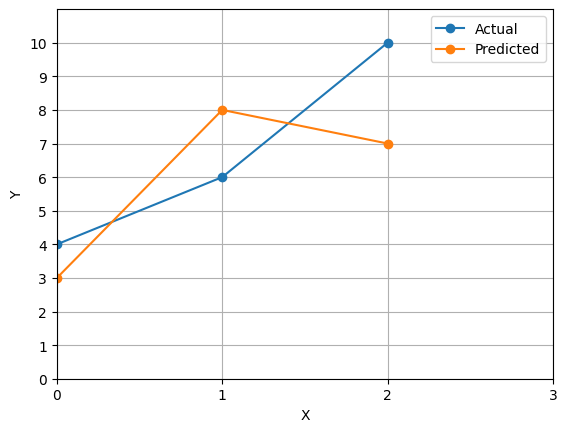

In [ ]:
# @title
# Drawing a graph of some example predicted and actual values
plt.plot(
    [0, 1, 2],
    [4, 6, 10],
    label="Actual",
    marker='o',
)
plt.plot(
    [0, 1, 2],
    [3, 8, 7],
    label="Predicted",
    marker='o',
)

plt.gca().set_xlabel("X")
plt.gca().set_ylabel("Y")
plt.gca().set_xlim([0, 3])
plt.gca().set_ylim([0, 11])
plt.gca().set_xticks(np.arange(0, 4, 1))
plt.gca().set_yticks(np.arange(0, 11, 1))
plt.grid()
plt.legend()
plt.show()

Remember for each point (at $x = 0, 1, \text{and } 2$):

1. Find the difference between the actual and predicted value
2. Square this difference
3. Get the average of all these squared differences

So we have the values:

| X | Y Actual | Y Predicted |
| - | - | - |
| 0 | 4 | 3 |
| 1 | 6 | 8 |
| 2 | 10 | 7 |

Then we find the difference between each and square the difference:

| X | Y Actual | Y Predicted | Difference | Difference Squared |
| - | - | - | - | - |
| 0 | 4 | 3 | 1 | 1 |
| 1 | 6 | 8 | -2 | 4 |
| 2 | 10 | 7 | 3 | 9 |

The average of $1$, $4$, and $9$ is:

$\frac{1 + 4 + 9}{3} = \frac{14}{3} \approx 4.6$

So that means our Mean Squared Error is about $4.6$!

### You Try - Mean Squared Error
Okay now you try. Given the graph below find the Mean Squared Error of the predicted vs actual value:

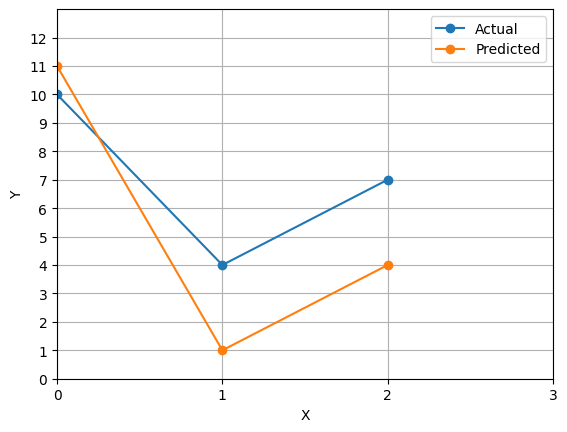

In [ ]:
# @title
# Drawing a graph of some example predicted and actual values
plt.plot(
    [0, 1, 2],
    [10, 4, 7],
    label="Actual",
    marker='o',
)
plt.plot(
    [0, 1, 2],
    [11, 1, 4],
    label="Predicted",
    marker='o',
)

plt.gca().set_xlabel("X")
plt.gca().set_ylabel("Y")
plt.gca().set_xlim([0, 3])
plt.gca().set_ylim([0, 13])
plt.gca().set_xticks(np.arange(0, 4, 1))
plt.gca().set_yticks(np.arange(0, 13, 1))
plt.grid()
plt.legend()
plt.show()

Remember for each point (at $x = 0, 1, \text{and } 2$):

1. Find the difference between the actual and predicted value
2. Square this difference
3. Get the average of all these squared differences

So we have the values:

| X | Y Actual | Y Predicted |
| - | - | - |
| 0 | 10 | 11 |
| 1 | 4 | 1 |
| 2 | 7 | 4 |


## Finding the Best Prediction
So, if we have a measurement (error) of how close our prediction matches the real data. Then our goal is to find a prediction with the lowest error. Aka the prediction which matches our data the best.

Using our equation $y = m \cdot x + b$ for our prediction, the goal is to find the combination of $m$ and $b$ with the lowest error.

Humans can do this intuitively, on the graph below you have the real data, and then a prediction line. There are also sliders to change the value of $m$ and $b$ for our prediction.

Importantly, we also have a box showing the current Mean Squared Error for the current $m$ and $b$ values. See if you can find the combination of $m$ and $b$ which get the lowest error!

In [ ]:
# @title
# Draw actual and predicted on graph, then show MSE
x = np.arange(0, 11, 1)
actual = np.array([
    0, 0.1, 0.5, 0.6, 0.7, 1, 1.3, 1.7, 2.1, 2.4, 2.6
])

mse_box = widgets.Text(f"Mean Squared Error = ...", disabled=True)
display.display(mse_box)

def graph(m, b):
    """Play with the 'm' and 'b' sliders above the graph to get the lowest MSE."""
    predicted = (m * x) + b
    mse = round(np.square(np.subtract(actual, predicted)).mean(), 2)
    mse_box.value = f"Mean Squared Error = {mse}"

    plt.plot(x, actual, marker='o', label="Actual")
    plt.plot(x, predicted, marker='o', label="Predicted")
    plt.gca().set_ylim([0, 10])
    plt.gca().set_xlim([0, 10])
    plt.grid()
    plt.xticks(np.arange(0, 11, 1))
    plt.yticks(np.arange(0, 11, 1))
    plt.legend()
    plt.draw()

interact(
    graph,
    m=widgets.FloatSlider(value=0.7, min=0, max=1, step=0.05),
    b=widgets.FloatSlider(value=3, min=0, max=10, step=0.1),
)

Text(value='Mean Squared Error = ...', disabled=True)

interactive(children=(FloatSlider(value=0.36, description='m', max=1.0, step=0.05), FloatSlider(value=0.19, de…

<function __main__.graph(m, b)>

## Automatic Training - The Problem
What you've basically just done is manually trained a model. This may work for a model with just 2 variables that we can tweak. But in a neural network (like ChatGPT) there can be hundreds of millions, or even **billions** of variables we need to find the right value for.

That's obviously way too many variables to find the right value of by dragging sliders around. What we need to do is write a program which can automatically find the best value for these variables.

## Automatic Training - Writing a Program
Having a number which represents error is super helpful for writing a program. We can tweak a variable and see if the value got better or worse. Just to simplify things lets only try changing the $m$ variable for now.

How do you think you would write a program which automatically finds the best value for $m$?

Think about what you did when you were changing the slider and looking at the MSE and graph above. Can you break the actions you took into simple steps which a computer could follow?

Try writing those steps as a list here:

1. first step
2. second step
3. ect

Good job trying to think of a program. Below is the correct answer:

- Change the $m$ variable by a little bit
- If the Mean Squared Error got worse:
  - We know we are probably changing the $m$ variable in the wrong direction
  - For example if $m = 1.0$ and we set it to $m = 1.1$ and the Mean Squared Error goes up
  - Then we know that we should probably be subtracting from $m$ instead of adding
- Keep changing the $m$ variable by a little bit until our Mean Squared Error is under a certain threshold

The program below does this. Try running it and seeing what it prints out and what the graph looks like:


Modified m by 0.05 and got m=1.05, got mse=22.64, prev mse=19.91
Whoops we are changing the m variable in the wrong direction
Modified m by -0.05 and got m=1.0, got mse=19.91, prev mse=22.64
Modified m by -0.05 and got m=0.95, got mse=17.36, prev mse=19.91
Modified m by -0.05 and got m=0.9, got mse=14.98, prev mse=17.36
Modified m by -0.05 and got m=0.85, got mse=12.78, prev mse=14.98
Modified m by -0.05 and got m=0.8, got mse=10.76, prev mse=12.78
Modified m by -0.05 and got m=0.75, got mse=8.91, prev mse=10.76
Modified m by -0.05 and got m=0.7, got mse=7.23, prev mse=8.91
Modified m by -0.05 and got m=0.65, got mse=5.73, prev mse=7.23
Modified m by -0.05 and got m=0.6, got mse=4.41, prev mse=5.73
Modified m by -0.05 and got m=0.55, got mse=3.25, prev mse=4.41
Modified m by -0.05 and got m=0.5, got mse=2.28, prev mse=3.25
Modified m by -0.05 and got m=0.45, got mse=1.48, prev mse=2.28
Modified m by -0.05 and got m=0.4, got mse=0.85, prev mse=1.48
Modified m by -0.05 and got m=0.35, go

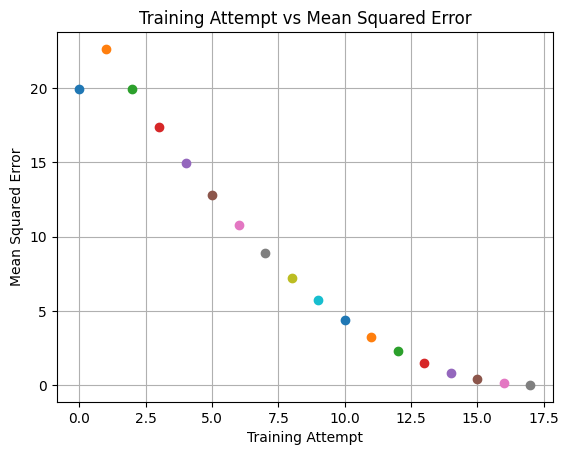

In [ ]:
x = np.arange(0, 11, 1)
actual = np.array([
    0, 0.1, 0.5, 0.6, 0.7, 1, 1.3, 1.7, 2.1, 2.4, 2.6
])

# This function returns the Mean Squared Error for a combination of m and b
def mse(m, b=0):
    predicted = (m * x) + b
    return np.square(np.subtract(actual, predicted)).mean()

# Initial value for m
current_m = 1
change_m_amount = 0.05

# Let's record the previous Mean Squared Error values so we can see if they're getting better or worse
prev_mse = mse(current_m)
plt.plot(0, prev_mse, marker='o')

# We will consider ourselves done if our Mean Squared Error is below this number
threshold_mse = 0.1

training_attempt = 1
while prev_mse > threshold_mse:
    # Change the m variable by a bit
    current_m = current_m + change_m_amount

    # Get the new Mean Squared Error
    current_mse = mse(current_m)
    print(f"Modified m by {change_m_amount} and got m={round(current_m, 2)}, got mse={round(current_mse, 2)}, prev mse={round(prev_mse, 2)}")

    # Put newest mse on a graph
    plt.plot(training_attempt, current_mse, marker='o')

    if current_mse > prev_mse:
        # Our error is getting worse
        # We probably changed the m variable in the wrong direction
        print("Whoops we are changing the m variable in the wrong direction")
        change_m_amount = change_m_amount * -1

    # Save new MSE value so we can see if the next attempt is worse or better
    prev_mse = current_mse
    training_attempt = training_attempt + 1

# Show results
print(f"The best value for m is {round(current_m, 2)}")

plt.title("Training Attempt vs Mean Squared Error")
plt.gca().set_xlabel("Training Attempt")
plt.gca().set_ylabel("Mean Squared Error")
plt.grid()
plt.show()

Here you can see that as training goes on the Mean Squared Error becomes less and less.

Don't worry if you don't understand all the Python code in the program above. Just make sure you understand the core idea of:

- We change $m$ by a small amount
- See if the Mean Squared Error got better or worse
- Adjust the amount we are changing by based on the MSE

The $m$ value which the program finds should be very similar to the one you found manually.

## Automatic Training - Reviewing Our First Attempt
The program we have is pretty good. But, there's one thing that isn't great about it. Look how initially the program tries to **increase** $m$ before realizing that makes the Mean Squared Error **worse**.

We don't want a program that just goes and guesses if it should be adding or subtracting from $m$. We want to know, without plugging in a new $m$ value if our Mean Squared Error will get higher (bad) or lower (good).

In mathematical terms we want to know: How does the value of $m$ affect our Mean Squared Error?

Does this question sound familiar to you? Think back to some of your math classes. Can we **calculate** how Mean Squared Error changes in relation to $m$?

...  
...

The answer is **derivatives**!



## Automatic Training - What do Derivatives Tell Us?
Before we go looking at derivatives of Mean Squared Error and our model ($y = m \cdot x + b$) let's just look and see what derivatives generally tell us.

Let's look at the equation $y = 2x$ and its derivative $\frac{dy}{dx} = 2$:

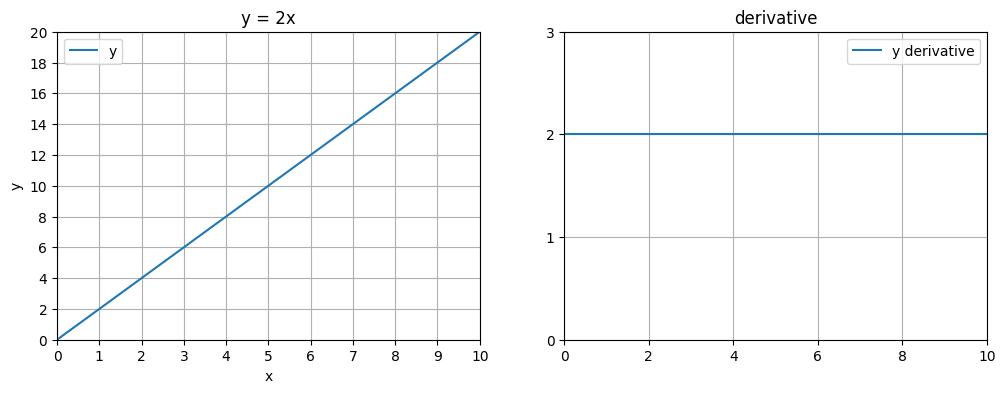

In [ ]:
# @title
# Graph y = 2x and its derivative
x = np.arange(0, 11, 1)
y = 2 * x
y_deriv = 2

plt.subplots(1, 2, figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, y, label="y")
plt.gca().set_xlabel("x")
plt.gca().set_ylabel("y")
plt.grid()
plt.gca().set_xlim(0, 10)
plt.gca().set_ylim(0, 20)
plt.gca().set_xticks(np.arange(0, 11, 1))
plt.gca().set_yticks(np.arange(0, 22, 2))
plt.title("y = 2x")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, [y_deriv] * len(x), label="y derivative")
plt.grid()
plt.gca().set_xlim(0, 10)
plt.gca().set_ylim(0, 3)
plt.gca().set_yticks(np.arange(0, 4, 1))
plt.legend()
plt.title("derivative")
plt.show()

The derivative is just a fancy name for the slope of the line measured exactly at a specific point. Since $y = 2x$ is a linear equation (it's only a straight line) the derivative at any point is the same as the slope.

You can see that the derivative of $y = 2x$ is $2$. We can verify that the derivative is correct by looking at 2 points:

- $(1, 2)$
- $(2, 4)$

The $y$ value for these points increases by $2$ (which is the derivative)!

Now an equation like $y = 2x$ is boring because the derivative is the slope and it never changes.

Let's take a look at $y = x^2$ and its derivative $\frac{dy}{dx} = 2x$.

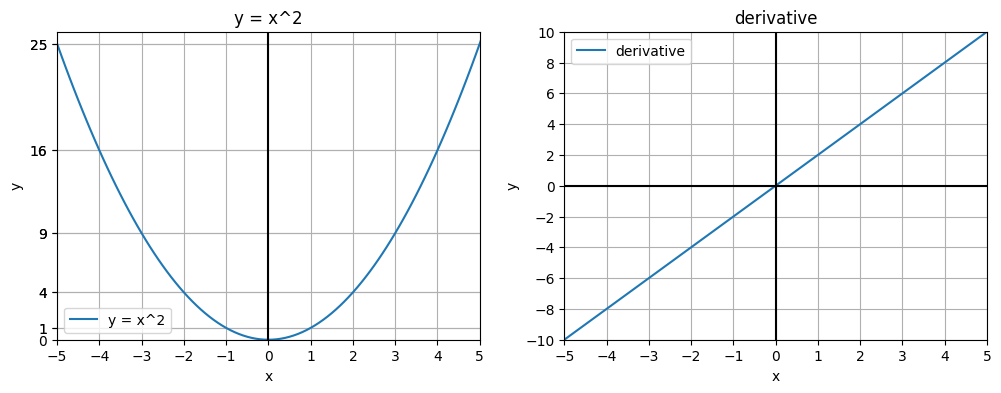

In [ ]:
# @title
# Graph y = x^2 and its derivative
x = np.arange(-5, 6, 0.1)
y = x**2
y_deriv = 2 * x

plt.subplots(1, 2, figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("y = x^2")
plt.plot(x, y, label="y = x^2")
plt.gca().set_xlim(-5, 5)
plt.gca().set_ylim(0, 26)
plt.gca().set_xlabel("x")
plt.gca().set_ylabel("y")
plt.gca().set_xticks(np.arange(-5, 6, 1))
plt.gca().set_yticks(np.arange(-5, 6, 1)**2)
plt.axvline(x=0, color='black')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.title("derivative")
plt.plot(x, y_deriv, label="derivative")
plt.gca().set_xlim(-5, 5)
plt.gca().set_ylim(-10, 10)
plt.gca().set_xticks(np.arange(-5, 6, 1))
plt.gca().set_yticks(np.arange(-10, 11, 2))
plt.gca().set_xlabel("x")
plt.gca().set_ylabel("y")
plt.axhline(y=0, color='black')
plt.axvline(x=0, color='black')
plt.grid()
plt.legend()
plt.show()

Here the derivative is a lot more interesting:

- The derivative changes as $x$ changes
- The derivative changes sign
- Since $y = x^2$ is non-linear (it has curves instead of only straight lines) the derivative isn't as easy to see just by looking at the slope of the entire line

Let's take a look at each of these differences individually:


### Derivatives - Changes as $x$ Changes
This is a pretty interesting observation of the derivative of $y = x^2$. What does the derivative increasing or decreasing mean?

When the derivative is:

- Greater is means the value of $y$ increases faster
- Less it means the value of $y$ increases slower

When we're training a model this is useful. As it tells us how much we need to change a variable to get the output to change:

- If the derivative is big it means we don't have to change the variable much to change the Mean Squared Error
- If the derivative is small it means we have to change the variable a lot to change the Mean Squared Error

### Derivatives - Sign Changes
This is one of the more important things to pay attention to about derivatives. The sign of a derivative tells us what will happen when we increase $x$.

Look at the graph of $y = x^2$ above:

- At $x = -2$ the value of $y$ is $4$
- At $x = -1$ the value of $y$ is $1$

By increasing $x$ by $1$ the value of $y$ has decreased by $3$. If we look at the derivative we could know this.

- At $x = -2$ the derivative is $-4$
- At $x = -1$ the derivative is $-2$

Since the derivative is negative we can know that increasing $x$ will decrease $y$. And vise versa if the deriviative is positive we know increaseing $x$ will increase $y$.

| - | Derivative | Y Change |
| - | - | - |
| **Increase X** | Negative | Decrease |
| **Increase X** | Positive | Increase |
| **Decrease X** | Negative | Increase |
| **Decrease X** | Positive | Decrease |

This solves our biggest problem with training from earlier. Using the derivative we can now know exactly which direction to change $m$.

### Derivatives - Non-Linear
Derivatives act a bit interestingly when we don't have a linear function. This makes using the derivative a bit intersting during training.

The derivative isn't the same at every point. So we can't use it to predict the exact $y$ value when we increase a variable (unlike linear equations).

- At $x = 2$ the derivative is $4$
- You'll notice that the change between $x = 2$ and $x = 3$ isn't equal to the deriviate
  - $(2, 4)$
  - $(3, 9)$
- The value of $y$ changes by $5$ while $\frac{dy}{dx} = 4$
- This is because the derivative is the slope of the line exactly at an $x$ value
  - At other $x$ values the derivative will be different (for non-linear equations)

To underscore this, check out the derivative at $x = 2$ graphed as a line:


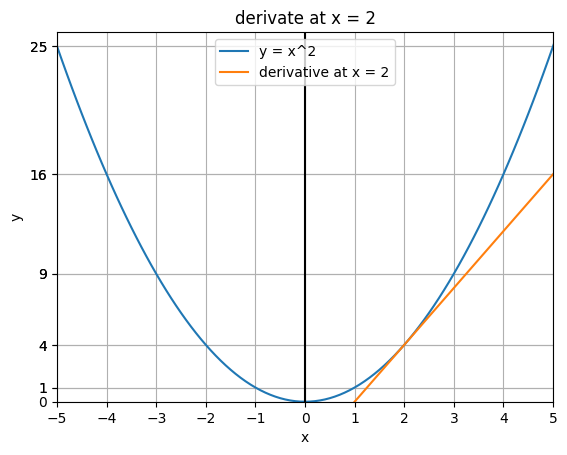

In [ ]:
# @title
x = np.arange(-5, 6, 0.1)
y = x**2
y_deriv_at_x_2 = (4 * x) - 4

plt.title("derivate at x = 2")
plt.plot(x, y, label="y = x^2")
plt.plot(x, y_deriv_at_x_2, label="derivative at x = 2")
plt.gca().set_xlim(-5, 5)
plt.gca().set_ylim(0, 26)
plt.gca().set_xlabel("x")
plt.gca().set_ylabel("y")
plt.gca().set_xticks(np.arange(-5, 6, 1))
plt.gca().set_yticks(np.arange(-5, 6, 1)**2)
plt.axvline(x=0, color='black')
plt.grid()
plt.legend()
plt.show()

Here we have the equation $y = x^2$ graphed along side the derivate at $x = 2$ as a line:

- You can see right where $x = 2$ the derivate line (orange) intercepts the $y = x^2$ line (blue)
- But before $x = 2$ the blue line's slope is less, and after $x = 2$ the slope is more

So from this we know: The derivative at a certain $x$ only tells us the slope of the line **exactly** at that $x$.

## Derivatives - Wrap Up
Okay let's review what we've learned about derivatives:

- The sign of the derivative (positive or negative) helps us know how an equation will react if we change a variable
- The intensity of the derivative (big or small) helps us know how much we need to tweak a variable (a lot or a little) to get our output variable to reach our target value

## Automatic Training - Derivatives
The end goal of training is to reduce the Mean Squared Error to the lowest value we can get it. This will mean that our model's predictions are as close to the actual data as possible.

Just as a refresher we're trying to train our model $y = m \cdot x + b$ to find the best values of $m$ and $b$.

Let's bring derivatives into the training process now. Since we are trying to affect the value of the Mean Squared Error we should take the derivative of the Mean Squared Error (MSE) Equation:

- We can take the derivative of $MSE$ in relation to $m$ ($\frac{dmse}{dm}$) to see how the MSE changes as we change $m$
- Similarily we can take the derivative of $MSE$ in relation to $b$ ($\frac{dmse}{db}$) to see how the MSE changes as we change $b$

Now, we could use our calculus skills to derrive the Mean Squared Error formula based on our model equation ($y = m \cdot x + b$):

- That would work for a simple equation like ours
- Although it would still be a huge pain, just go and look at that MSE equation, do **you** know how to derrive that
- I'll be honest it's been way too long since I took calculus to do that

Regardless, modern machine learning models have hundreds or billions of variables. And we definitely can't do that by hand.

## Automatic Training - Programatically Getting Derivatives
Luckily people have already written Python code which gets you the derivative of any function that can be derrived. For our example we will be using a tool named PyTorch, which is very popular in the machine learning community.

Our Python code is going to start looking a little weird. This is because PyTorch needs to understand our equation:

- Instead of just defining variables like:
  ```python
  m = 1.0
  b = 2.0
  ```
- Our code will look like this:
  ```python
  m = torch.tensor(1.0)
  b = torch.tensor(2.0)
  ```
- We need to create what PyTorch calls a "Tensor"
  - Tensors are pretty cool, and we'll get more in to them later
  - For now just think of them as special variables which allow us to get the derivative of a function in Python

In [ ]:
# 1. First we define m and b
# These are the variables we want to get the derivative of y in relation to
# Notice how we have to provide requires_grad=True
# This tells PyTorch that we want to be able to get the derivative in relation to this variable
m = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# 2. Then we set up our model equation
x = torch.arange(0, 11, 1) # Make a tensor with the values between 0 and 11 (0, 1, 2, ..., 10, 11)
y = (m*x) + b

# 3. Next lets define Mean Squared Error equation for our model
actual = torch.tensor([
    0, 0.1, 0.5, 0.6, 0.7, 1, 1.3, 1.7, 2.1, 2.4, 2.6
])
mse = torch.square(torch.subtract(actual, y)).mean()

# 4. Now we call a special function on y called "backward()"
# This computes the derivative of mse in relation to any variable which has requires_grad=True
mse.backward()

# 5. Now we can get the derivative of mse in relation to m or b
print(f"dmse/dm is {m.grad}, dmse/db is {b.grad}")

dmse/dm is 52.763641357421875, dmse/db is 7.636363983154297


By calling `mse.backwards()` we can then get $\frac{dmse}{dm} \approx 52.76$ and $\frac{dmse}{db} \approx 7.64$.

This is super helpful. We can directly see how both $m$ and $b$ affect the Mean Squared Error:

- Both derivatives are positive
  - This means if increase $m$ or $b$ the Mean Squared Error will **increase** (our model will get worse)
  - So we should **decrease** both variables to get a better (and smaller) Mean Squared Error
- The derivative of $m$ is way bigger than the derivative of $b$
  - This means $m$ has a way bigger influence on the Mean Squared error than $b$

Let's use this knowledge to revise our automatic training program from earlier:

1. While Mean Squared Error is above a threshold
2. Get the derivative of Mean Squared Error in relation to $m$ ($\frac{dmse}{dm}$)
3. Modify $m$ in the opposite direction of the derivative

Before our training program only updated $m$ for simplicity. But now the whole training process is easier. So we can also update our training program to update $b$ as well. We'll just apply the same logic to $b$ as described above.

Modify m+-0.6276, b+-0.0964, m=0.37, b=0.9, mse=28.55
Modify m+-0.1787, b+-0.0317, m=0.19, b=0.87, mse=2.63
Modify m+-0.0504, b+-0.0132, m=0.14, b=0.86, mse=0.51
Modify m+-0.0138, b+-0.0079, m=0.13, b=0.85, mse=0.33
Modify m+-0.0034, b+-0.0063, m=0.13, b=0.84, mse=0.32
Modify m+-0.0004, b+-0.0059, m=0.13, b=0.84, mse=0.31
Modify m+0.0005, b+-0.0057, m=0.13, b=0.83, mse=0.31
Modify m+0.0007, b+-0.0056, m=0.13, b=0.83, mse=0.31
Modify m+0.0008, b+-0.0056, m=0.13, b=0.82, mse=0.3
Modify m+0.0008, b+-0.0056, m=0.13, b=0.82, mse=0.3
Modify m+0.0008, b+-0.0055, m=0.13, b=0.81, mse=0.3
Modify m+0.0008, b+-0.0055, m=0.13, b=0.81, mse=0.29
Modify m+0.0008, b+-0.0055, m=0.13, b=0.8, mse=0.29
Modify m+0.0008, b+-0.0054, m=0.13, b=0.79, mse=0.29
Modify m+0.0008, b+-0.0054, m=0.13, b=0.79, mse=0.28
Modify m+0.0008, b+-0.0054, m=0.13, b=0.78, mse=0.28
Modify m+0.0008, b+-0.0054, m=0.13, b=0.78, mse=0.28
Modify m+0.0008, b+-0.0053, m=0.13, b=0.77, mse=0.27
Modify m+0.0008, b+-0.0053, m=0.14, b=0.77, 

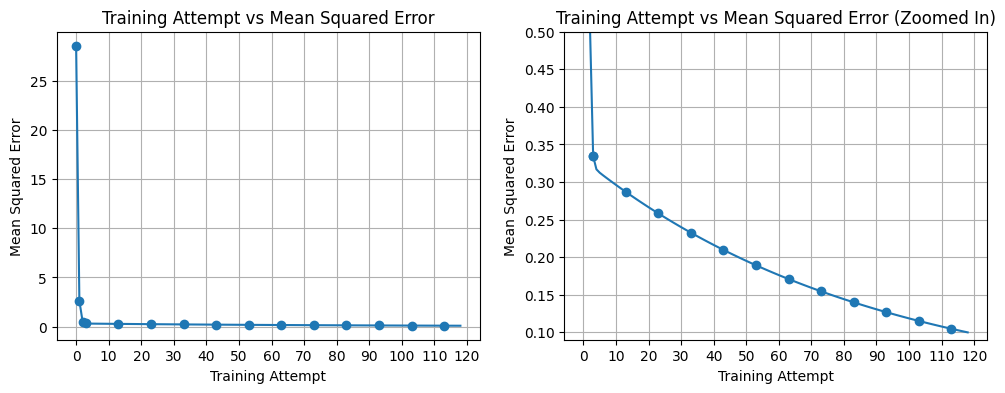

In [ ]:
x = torch.arange(0, 11, 1)
actual = torch.tensor([
    0, 0.1, 0.5, 0.6, 0.7, 1, 1.3, 1.7, 2.1, 2.4, 2.6
])

current_m = 1.0
current_b = 1.0

# Setup y = m * x + b and MSE
def mse(m_, b_):
    m = torch.tensor(m_, requires_grad=True)
    b = torch.tensor(b_, requires_grad=True)
    y = (m * x) + b
    return torch.square(torch.subtract(actual, y)).mean(), m, b

# We will consider ourselves done if our Mean Squared Error is below this number
threshold_mse = 0.1

# We multiply the derivative by this number when updating the variables
learning_rate = 0.01

training_attempt = 1
mse_plot = []
while training_attempt < 1_000:
    # Calculate the derivative
    mse_, m, b = mse(current_m, current_b)
    mse_.backward()

    # Change the m variable by a bit proportional to the derivative
    change_m_amount = learning_rate * m.grad.item() * -1
    change_b_amount = learning_rate * b.grad.item() * -1

    current_m = current_m + change_m_amount
    current_b = current_b + change_b_amount

    # Get the new Mean Squared Error
    print(f"Modify m+{round(change_m_amount, 4)}, b+{round(change_b_amount, 4)}, m={round(current_m, 2)}, b={round(current_b, 2)}, mse={round(mse_.item(), 2)}")

    # Put newest mse on a graph
    mse_plot.append(mse_.detach())

    if mse_ <= threshold_mse:
        break

    training_attempt = training_attempt + 1

# Show results
print(f"END: m={round(current_m, 2)}, b={round(current_b, 2)}, mse={round(mse(current_m, current_b)[0].item(), 3)}, after {training_attempt+1} rounds of training")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 3, 1), mse_plot[:3], marker='o', color='tab:blue')
plt.plot(np.arange(3, training_attempt, 1), mse_plot[3:], marker='o', color='tab:blue', markevery=10)
plt.title("Training Attempt vs Mean Squared Error")
plt.gca().set_xlabel("Training Attempt")
plt.gca().set_ylabel("Mean Squared Error")
plt.gca().set_xticks(np.arange(0, training_attempt+2, 10))
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 4, 1), mse_plot[:4], marker='o', color='tab:blue')
plt.plot(np.arange(3, training_attempt, 1), mse_plot[3:], marker='o', color='tab:blue', markevery=10)
plt.title("Training Attempt vs Mean Squared Error (Zoomed In)")
plt.gca().set_xlabel("Training Attempt")
plt.gca().set_ylabel("Mean Squared Error")
plt.gca().set_ylim(0.09, 0.5)
plt.gca().set_xticks(np.arange(0, training_attempt+2, 10))
plt.grid()
plt.show()

Excellent! Our training worked! Now we have have values for $m$ and $b$ which we can use in $y = m \cdot x + b$ to predict future plant growth.

This approach using derivatives has several advantages to our previous attempt:

- Values of $m$ and $b$ are adjusted proportionally based on how much either would change the Mean Squared Error
- Mean Squared Error starts decreasing immediately, unlike our past attempt where we changed $m$ in the wrong direction and the error got worse
- It's easier to find the correct value for multiple variables

Let's take our values for $m$ and $b$ and graph them next to the real data:


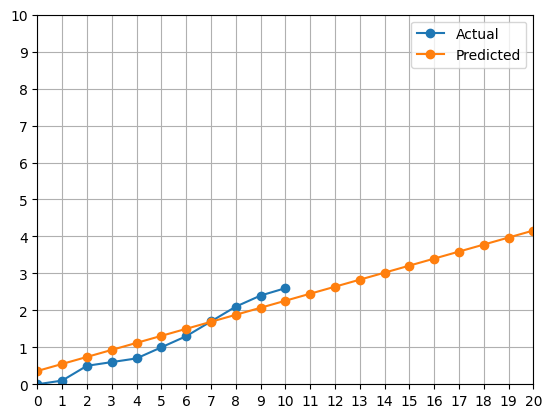

In [ ]:
x1 = np.arange(0, 11, 1)
x2 = np.arange(0, 21, 1)
actual = np.array([
    0, 0.1, 0.5, 0.6, 0.7, 1, 1.3, 1.7, 2.1, 2.4, 2.6
])

m = 0.19
b = 0.36

predicted = (m * x2) + b
mse_box.value = f"Mean Squared Error = {mse}"

plt.plot(x1, actual, marker='o', label="Actual")
plt.plot(x2, predicted, marker='o', label="Predicted")
plt.gca().set_ylim([0, 10])
plt.gca().set_xlim([0, 20])
plt.grid()
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 11, 1))
plt.legend()
plt.draw()

Our predicted line looks pretty good. And now we have a model that can predict future plant growth.

# Review
Let's review what we've learned so far:

- We can take an equation like $y = m \cdot x + b$ and find the correct $m$ and $b$ values to match our real data
- We measure how close our model ($y = m \cdot x + b$) is to the real data with error
  - Here we use Mean Squared Error
  - But there are other choices
- To find the correct $m$ and $b$ values we use derivatives to see how each variable affects the error
- We keep nudging the $m$ and $b$ values until the error is low enough

# Neural Networks
So far we've just been learning about mathematical modeling. This is the basis on which neural networks are built on.

So what are neural networks?

- They are modeled on the way brains work
- Made up of a bunch of **neurons**
- Neurons are highly connected

<img alt="Image of neurons in the brain" src="https://github.com/catvec/putney-mit-technology-camp/blob/main/assets/what-is-ai/neurons.webp?raw=true" width="800px" />

Let's start at the smallest building block, a neuron, and then work our way up to a full network.

## Neurons
Here is an image of a neuron:

![Image of a single neuron](https://github.com/catvec/putney-mit-technology-camp/blob/main/assets/what-is-ai/single-neuron.png?raw=true)

A neuron is composed of:

- Inputs ($x_i$): Values fed in to the neuron, these are the outputs from other neurons
- Weights ($w_i$): Input values are multiplied each by their own weight ($x_i \cdot w_i$)
  - These are the values we will change to train our neuron

Say a neuron as 4 inputs ($x_1$, $x_2$, $x_3$, and $x_4$). It will also have the same number of weights ($w_1$, $w_2$, $w_3$, and $w_4$).

These inputs and weights are multiplied and added up like so:  
$(x_1 \cdot w_1) + (x_2 \cdot w_2) + (x_3 \cdot w_3) + (x_4 \cdot w_4)$

Neurons also have:

- Bias ($b$): Added to the sum of all the inputs and their weights
  - We also change this value to train our neuron
- Activation function ($a$): The sum of all the inputs plus the bias are run through this function
  - This result is used as the output of the neuron
  - This function is how the neuron "decides" if all the inputs big enough to output
  - These are just normal math functions which take a single input and output a number

### Activation Functions
The activation function used in neurons are pretty important. They are the math which takes in all the inputs and decides what the output of the neuron should be.

A pretty common activation function is $tanh$. It's okay if you haven't heard of $tanh$, I hadn't before. To get familiar with it let's see what $tanh$ looks like on a graph:

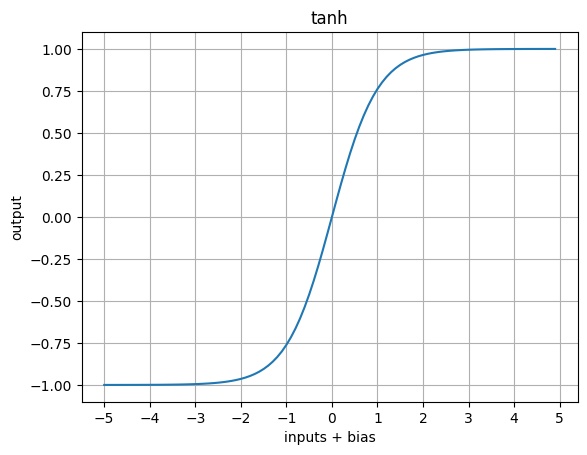

In [132]:
# @title
x = np.arange(-5, 5, 0.1)
y = np.tanh(x)

plt.plot(x, y)
plt.grid()
plt.title("tanh")
plt.gca().set_xlabel("inputs + bias")
plt.gca().set_ylabel("output")
plt.gca().set_xticks(np.arange(-5, 6, 1))
plt.show()

$tanh$ has some useful properties:

- The value will always be between $-1$ and $1$ (inclusive)
- It doesn't get overwhelmed by extremely large or extremely small inputs
  - Instead it just outputs $-1$ or $1$ respectively in these cases
- Preserves middle value inputs
  | Input | $tanh$ |
  | - | - |
  | -1.5 | -0.91 |
  | -1 | -0.76 |
  | -0.75 | -0.64 |
  | -0.5 | -0.42 |
  | 0.5 | 0.42 |
  | 0.75 | 0.64 |
  | 1 | 0.76 |
  | 1.5 | 0.91 |

## Neuron - Intuition
Now that we know the definitions of each part of a neuron, let's start to think about what their purposes are.

### Inputs and Weights
Each input is the output of another neuron.

The weights tell the neuron how much to pay attention to each input.

Imagine are measuring how much blue, red, and green is in an image. And those are the inputs to a neuron.

- If we are building a neural network that cares a lot about red the weight for red will probably be high
- While the weights for blue and green will probably be low

Just like we tried to find the right $m$ and $b$ values above to get the smallest error, we also try to find the right values of our neuron's weights to minimize the error.